# Univariate Analysis

## Objective

In this notebook, I will analyze each feature individually to understand its distribution and identify important patterns in the dataset. This helps build a better understanding of the data before exploring relationships between multiple variables.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [4]:
hotel_df = pd.read_csv("../data/hotel_bookings_cleaned.csv")

hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Dataset Information

Before starting the analysis, I loaded the cleaned dataset that was created in the previous notebook.

In [5]:
hotel_df.shape

(87370, 31)

Hotel Type

## Hotel Type

### Why am I analyzing this?

I want to see how bookings are distributed between City Hotels and Resort Hotels. This gives a quick overview of the dataset and helps me to identify which type of hotel receives more bookings.

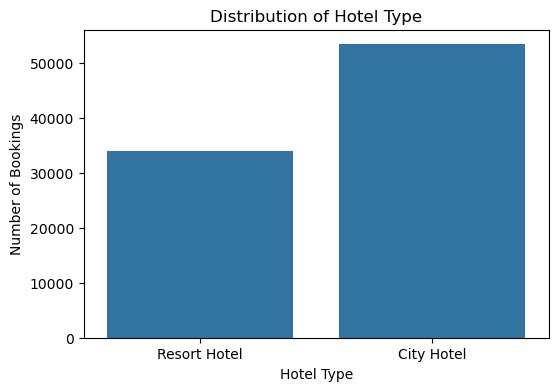

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=hotel_df,
    x="hotel"
)

plt.title("Distribution of Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

In [8]:
hotel_df["hotel"].value_counts()

hotel
City Hotel      53426
Resort Hotel    33944
Name: count, dtype: int64

In [9]:
hotel_df["hotel"].value_counts(normalize=True).mul(100).round(2)

hotel
City Hotel      61.15
Resort Hotel    38.85
Name: proportion, dtype: float64

### Observation

The bookings are not evenly distributed between the two hotel types. One hotel category has noticeably more bookings than the other.

### Insight

This suggests that customer demand is higher for one type of hotel. Understanding this difference can help hotels focus their marketing efforts and allocate resources more effectively.

Customer Type

## Customer Type

### Why am I analyzing this?

Customer type indicates the category of guests making the bookings. Analyzing this feature helps understand which group contributes the most to hotel reservations.

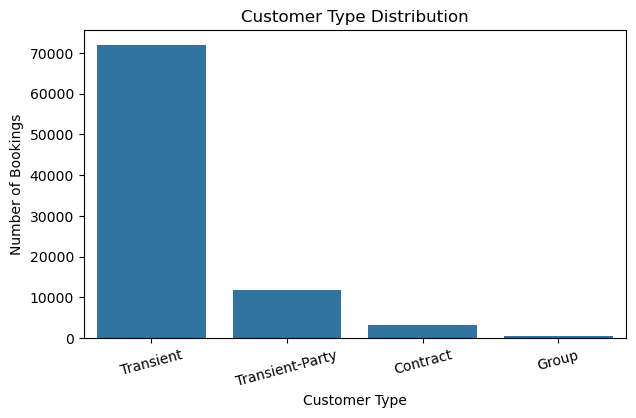

In [10]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=hotel_df,
    x="customer_type",
    order=hotel_df["customer_type"].value_counts().index
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=15)

plt.show()

In [11]:
hotel_df["customer_type"].value_counts()

customer_type
Transient          71968
Transient-Party    11719
Contract            3139
Group                544
Name: count, dtype: int64

In [12]:
hotel_df["customer_type"].value_counts(normalize=True).mul(100).round(2)

customer_type
Transient          82.37
Transient-Party    13.41
Contract            3.59
Group               0.62
Name: proportion, dtype: float64

### Observation

The majority of bookings belong to a single customer category, while the remaining categories account for a much smaller share of the dataset.

### Insight

This shows that hotels mainly serve one type of customer. Understanding customer composition can help businesses design services and promotional offers that better match their primary audience.

Meal

## Meal Preference

### Why am I analyzing this?

The `meal` feature shows the type of meal selected by guests while making a booking. Analyzing this helps understand which meal plans are most commonly preferred.

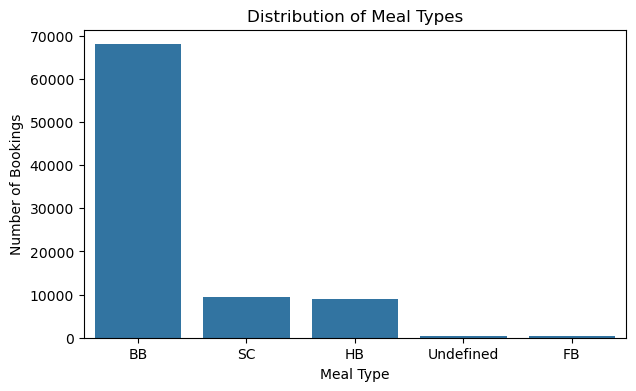

In [13]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=hotel_df,
    x="meal",
    order=hotel_df["meal"].value_counts().index
)

plt.title("Distribution of Meal Types")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")

plt.show()

In [14]:
hotel_df["meal"].value_counts()

meal
BB           67955
SC            9481
HB            9084
Undefined      490
FB             360
Name: count, dtype: int64

In [15]:
hotel_df["meal"].value_counts(normalize=True).mul(100).round(2)

meal
BB           77.78
SC           10.85
HB           10.40
Undefined     0.56
FB            0.41
Name: proportion, dtype: float64

### Observation

One meal type accounts for the majority of bookings, while the remaining meal plans are selected less frequently.

### Insight

Knowing the most preferred meal option can help hotels manage food inventory and improve meal planning based on customer demand.

Market Segment

## Market Segment

### Why am I analyzing this?

The `market_segment` feature represents the source through which customers make their bookings. Understanding this distribution helps identify the major channels contributing to hotel reservations.

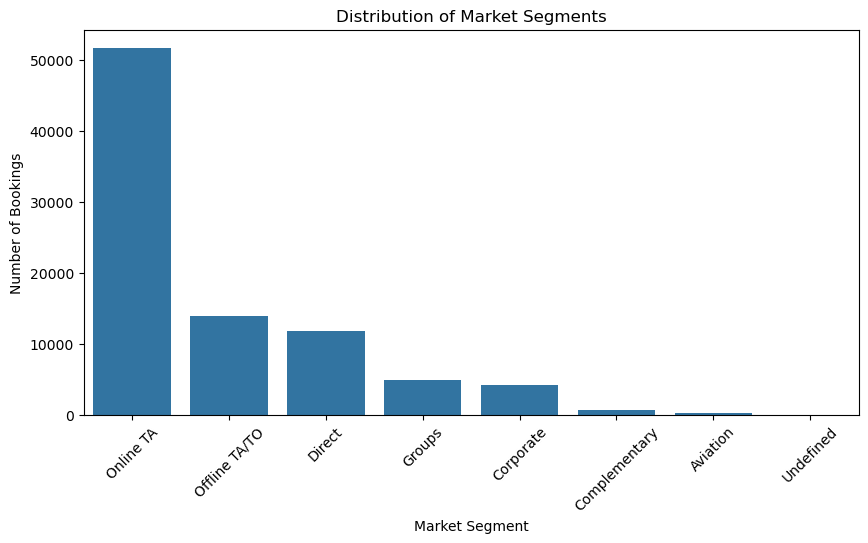

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=hotel_df,
    x="market_segment",
    order=hotel_df["market_segment"].value_counts().index
)

plt.title("Distribution of Market Segments")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

In [17]:
hotel_df["market_segment"].value_counts()

market_segment
Online TA        51613
Offline TA/TO    13886
Direct           11798
Groups            4940
Corporate         4202
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

### Observation

Bookings are concentrated in a few market segments, while several others contribute only a small portion of the total reservations.

### Insight

This information helps identify the most effective booking sources and can support future marketing and partnership decisions.

Distribution Channel

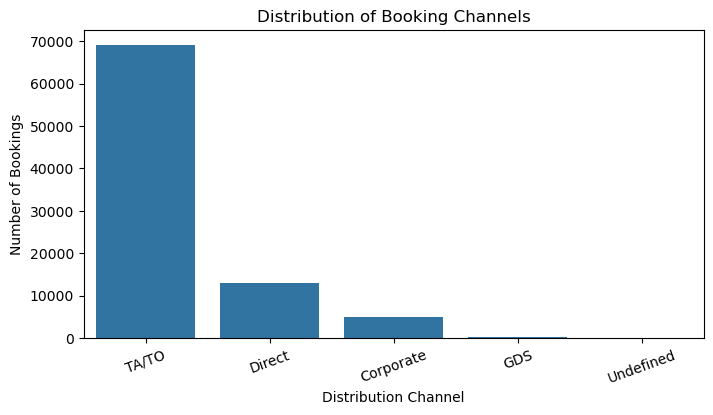

In [20]:
plt.figure(figsize=(8,4))
sns.countplot(
    data = hotel_df,
    x="distribution_channel",
    order=hotel_df["distribution_channel"].value_counts().index
            )
plt.title("Distribution of Booking Channels")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=20)

plt.show()

Reserved Room Type

## Reserved Room Type

### Why am I analyzing this?

The `reserved_room_type` feature shows the type of room selected by customers at the time of booking. Analyzing this feature helps me understand which room categories are preferred the most.

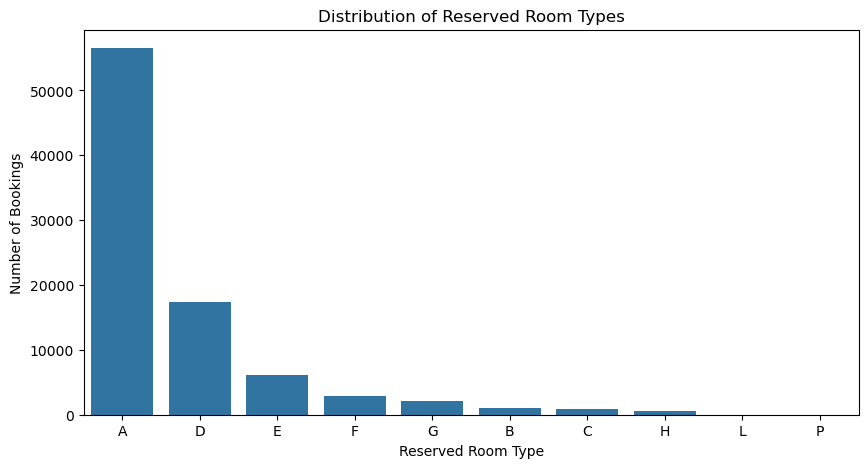

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=hotel_df,
    x="reserved_room_type",
    order=hotel_df["reserved_room_type"].value_counts().index
)

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Reserved Room Type")
plt.ylabel("Number of Bookings")

plt.show()

### Observation

Most bookings are concentrated in a few room categories, while the remaining room types have comparatively fewer reservations.

### Insight

The popularity of specific room types can help hotels plan room allocation, pricing strategies, and inventory management more effectively.

Deposit Type

## Deposit Type

### Why am I analyzing this?

The `deposit_type` feature tells whether a customer paid a deposit while making the booking. Analyzing this feature helps me understand the booking policy followed by most customers.

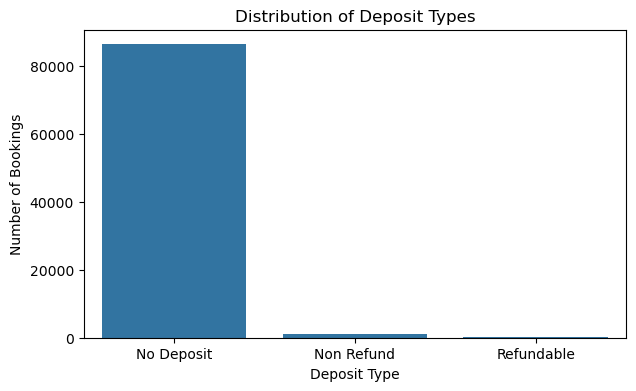

In [22]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=hotel_df,
    x="deposit_type",
    order=hotel_df["deposit_type"].value_counts().index
)

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")

plt.show()

### Observation

Most bookings fall under the **No Deposit** category, while only a small number of customers choose refundable or non-refundable deposits.

### Insight

This indicates that customers generally prefer booking without paying an advance deposit. Hotels may use flexible booking policies to attract more customers, while non-refundable bookings likely help reduce cancellation risk.

Arrival Date Analysis

# Arrival Date Analysis

Arrival-related features help me understand when customers prefer to book hotels. By analyzing the arrival month, week, and day of the week, I can identify seasonal trends and booking patterns throughout the year.

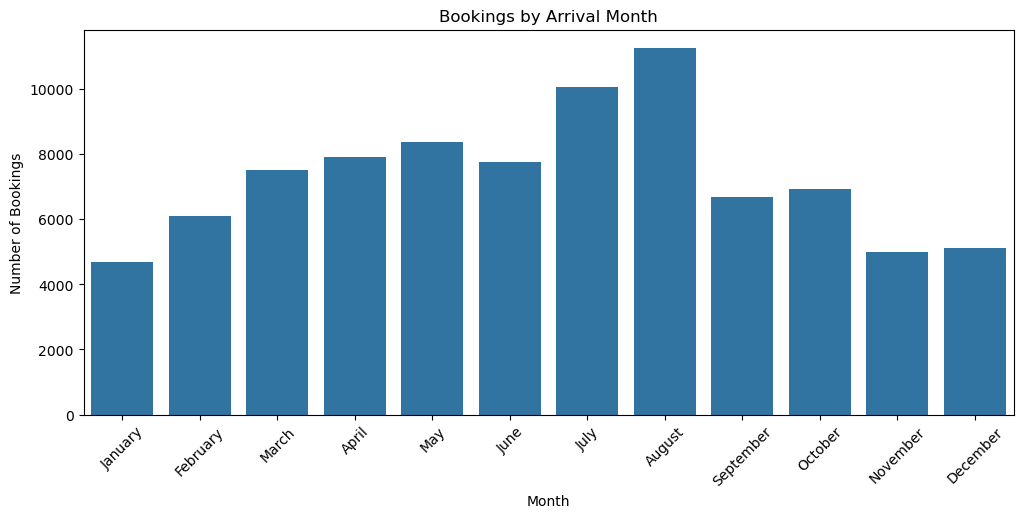

In [23]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=hotel_df,
    x="arrival_date_month",
    order=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ]
)

plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

### Observation

Booking demand varies across different months. Some months receive noticeably more bookings, while others experience lower demand.

### Insight

These seasonal trends can help hotels plan staffing, pricing, and promotional activities based on expected customer demand throughout the year.

Arrival Day of Week

## Arrival Day of Week

### Why am I analyzing this?

The `arrival_date_day_of_month` feature shows the day of the month on which guests are scheduled to arrive. Analyzing this feature helps me understand how bookings are distributed throughout the month.

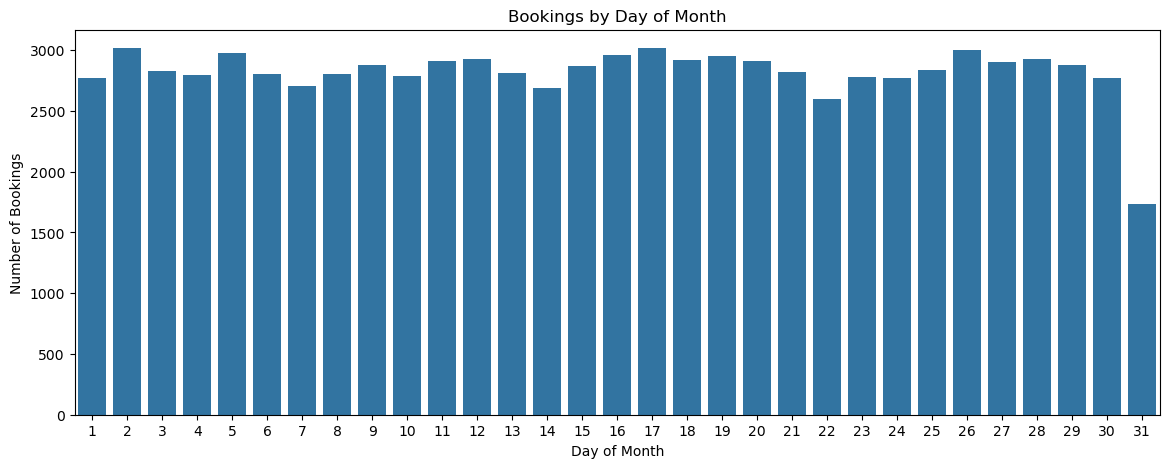

In [24]:
plt.figure(figsize=(14, 5))

sns.countplot(
    data=hotel_df,
    x="arrival_date_day_of_month"
)

plt.title("Bookings by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Number of Bookings")

plt.show()

In [25]:
hotel_df["arrival_date_day_of_month"].value_counts().sort_index()

arrival_date_day_of_month
1     2769
2     3015
3     2833
4     2798
5     2980
6     2804
7     2704
8     2808
9     2878
10    2785
11    2915
12    2928
13    2812
14    2692
15    2868
16    2957
17    3018
18    2923
19    2949
20    2915
21    2822
22    2601
23    2776
24    2774
25    2837
26    3000
27    2902
28    2924
29    2880
30    2770
31    1733
Name: count, dtype: int64

### Observation

Bookings are distributed across all days of the month, with some days showing slightly higher booking counts than others.

### Insight

Understanding daily booking patterns can help hotels anticipate customer arrivals and improve operational planning.

Arrival Week Number

## Arrival Week Number

### Why am I analyzing this?

The `arrival_date_week_number` feature represents the week of the year in which guests are scheduled to arrive. Analyzing this feature helps identify periods of high and low booking activity throughout the year.

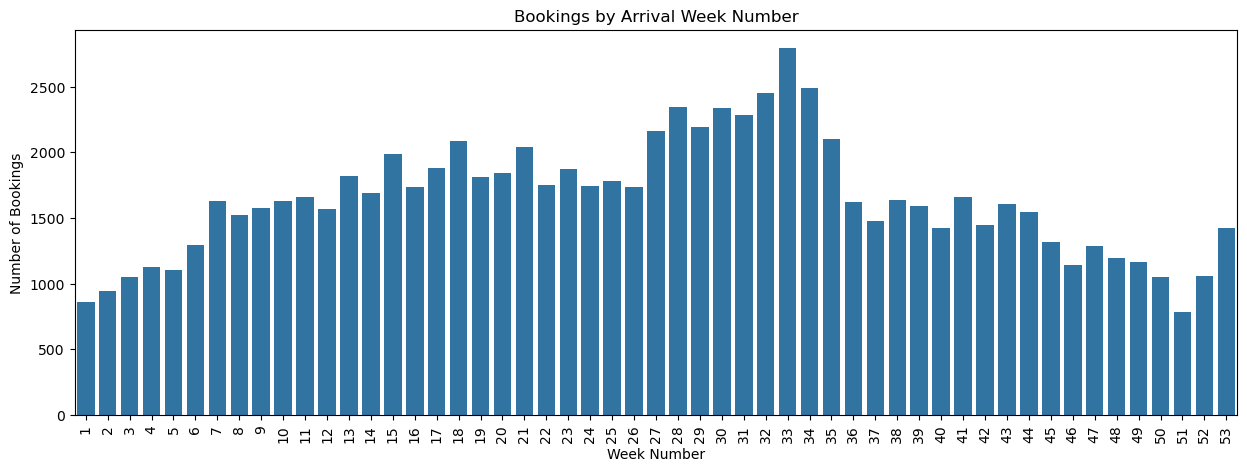

In [37]:
plt.figure(figsize=(15, 5))

sns.countplot(
    data=hotel_df,
    x="arrival_date_week_number"
)

plt.title("Bookings by Arrival Week Number")
plt.xlabel("Week Number")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=90)

plt.savefig(
    "../visuals/weekly_booking_trends.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [27]:
hotel_df["arrival_date_week_number"].value_counts().sort_index()

arrival_date_week_number
1      862
2      945
3     1049
4     1124
5     1101
6     1295
7     1629
8     1523
9     1579
10    1630
11    1657
12    1572
13    1817
14    1693
15    1989
16    1736
17    1878
18    2087
19    1813
20    1843
21    2043
22    1753
23    1872
24    1746
25    1786
26    1739
27    2166
28    2343
29    2197
30    2335
31    2286
32    2449
33    2793
34    2491
35    2105
36    1626
37    1474
38    1634
39    1590
40    1427
41    1663
42    1445
43    1605
44    1548
45    1314
46    1141
47    1288
48    1199
49    1169
50    1053
51     785
52    1061
53    1422
Name: count, dtype: int64

### Observation

Booking volumes vary across different weeks of the year, with certain weeks receiving noticeably more reservations.

### Insight

Weekly booking trends can help hotels identify peak travel periods and prepare resources accordingly.

Guest Composition

## Guest Composition

### Why am I analyzing this?

The number of adults and children in a booking provides an overview of the typical guest composition. Analyzing these features helps identify whether most bookings are made by individuals, couples, or families.

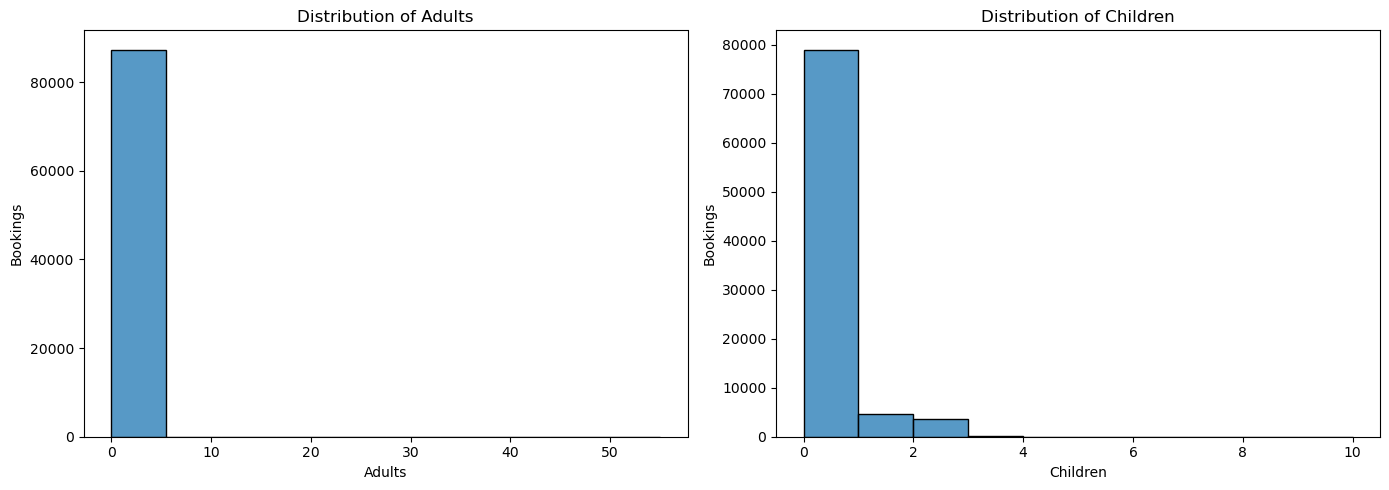

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=hotel_df,
    x="adults",
    bins=10,
    ax=axes[0]
)

axes[0].set_title("Distribution of Adults")
axes[0].set_xlabel("Adults")
axes[0].set_ylabel("Bookings")

sns.histplot(
    data=hotel_df,
    x="children",
    bins=10,
    ax=axes[1]
)

axes[1].set_title("Distribution of Children")
axes[1].set_xlabel("Children")
axes[1].set_ylabel("Bookings")

plt.tight_layout()
plt.show()

### Observation

Most bookings include one or two adults, while bookings with children are comparatively less frequent.

### Insight

The dataset indicates that couples and small groups make up a large share of hotel bookings, whereas family bookings with children are relatively fewer.

Booking Behaviour

## Booking Behaviour

### Why am I analyzing this?

Lead time shows how early customers book their stay, while ADR (Average Daily Rate) represents the average room price. Analyzing these features helps understand customer booking patterns and pricing distribution.

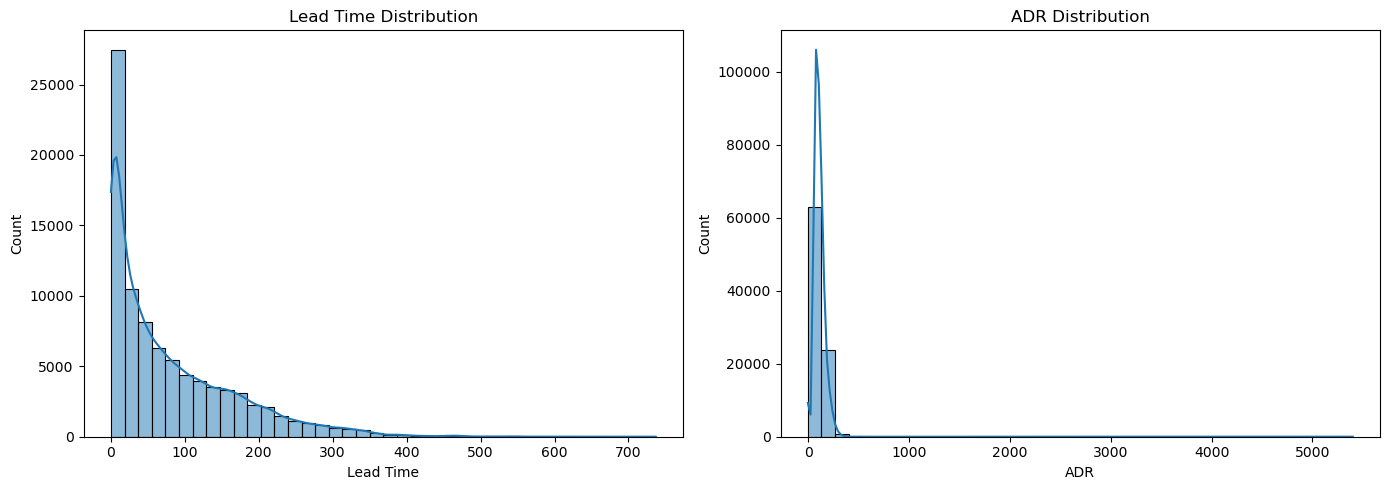

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    hotel_df["lead_time"],
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Lead Time Distribution")
axes[0].set_xlabel("Lead Time")

sns.histplot(
    hotel_df["adr"],
    bins=40,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("ADR Distribution")
axes[1].set_xlabel("ADR")

plt.tight_layout()
plt.show()

### Observation

Lead time is positively skewed, indicating that many bookings are made well before the arrival date. ADR values are concentrated within a specific price range, with a few higher-priced bookings acting as outliers.

### Insight

Understanding booking lead time helps hotels optimize reservation strategies, while ADR distribution provides insights into room pricing and revenue patterns.

 Length of Stay


## Length of Stay

### Why am I analyzing this?

The dataset contains separate columns for weekend nights and weekday nights. Analyzing both together helps me understand how long guests usually stay and whether they spend more nights during weekdays or weekends.

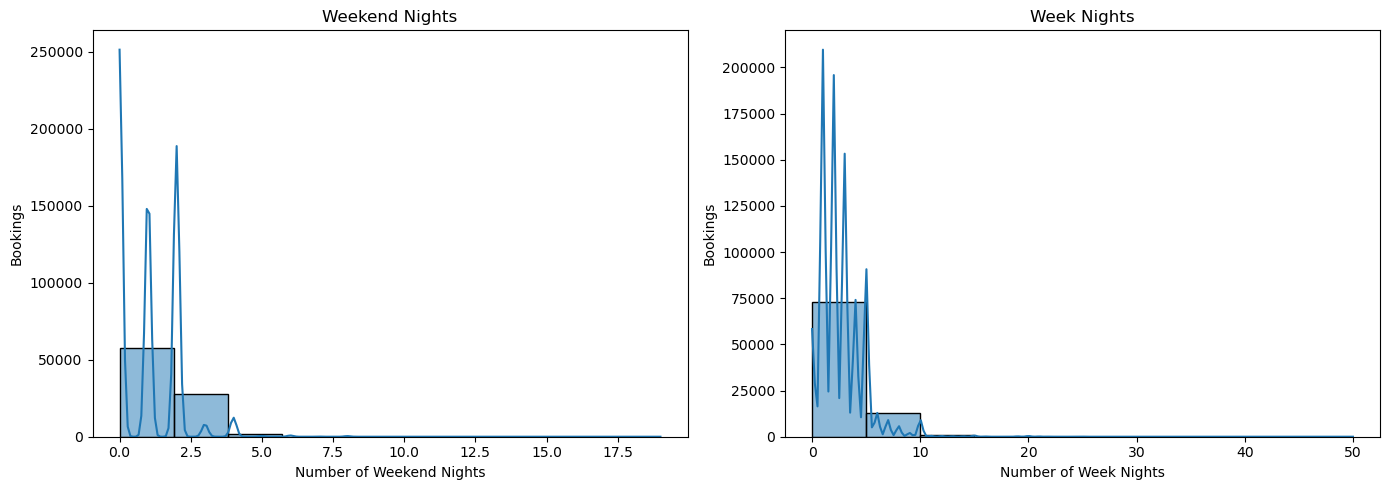

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=hotel_df,
    x="stays_in_weekend_nights",
    bins=10,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Weekend Nights")
axes[0].set_xlabel("Number of Weekend Nights")
axes[0].set_ylabel("Bookings")

sns.histplot(
    data=hotel_df,
    x="stays_in_week_nights",
    bins=10,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Week Nights")
axes[1].set_xlabel("Number of Week Nights")
axes[1].set_ylabel("Bookings")

plt.tight_layout()
plt.show()

In [31]:
hotel_df[["stays_in_weekend_nights", "stays_in_week_nights"]].describe()

,stays_in_weekend_nights,stays_in_week_nights
count,87370.000000,87370.000000
mean,1.005448,2.625798
std,1.031974,2.053692
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,4.000000
max,19.000000,50.000000


### Observation

Most guests stay for a small number of nights, with longer stays occurring less frequently. Weekday stays appear to be slightly more common than weekend stays.

### Insight

Understanding the typical length of stay can help hotels with room availability planning, pricing strategies, and forecasting occupancy.

Booking Modifications


## Booking Modifications

### Why am I analyzing this?

The `booking_changes` and `total_of_special_requests` features provide information about customer behavior after making a reservation. Analyzing these features helps understand how often bookings are modified and how frequently guests make additional requests.

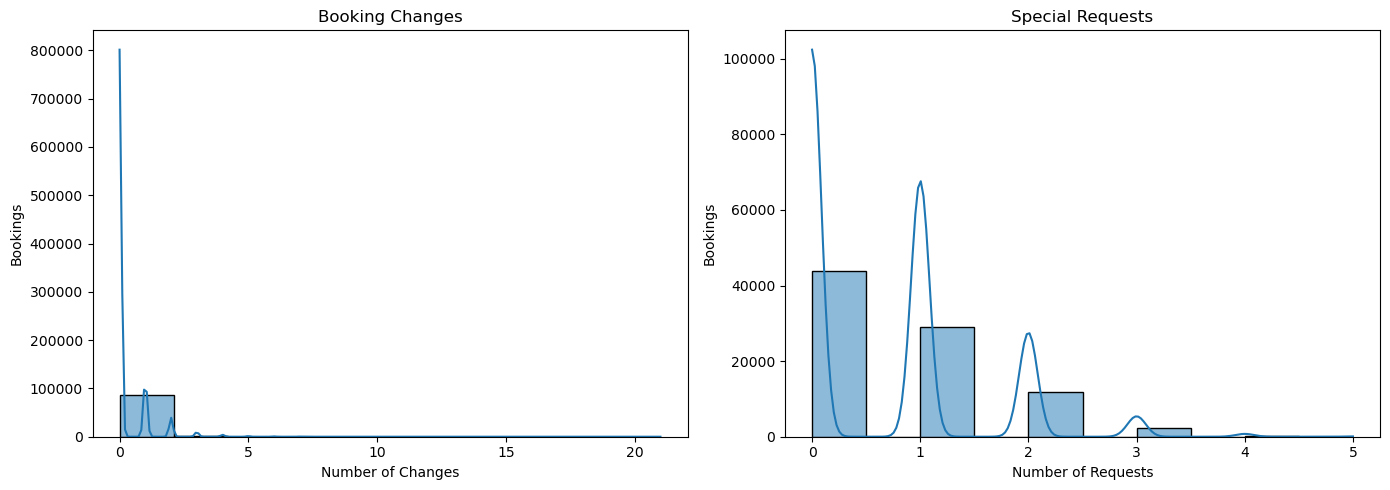

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=hotel_df,
    x="booking_changes",
    bins=10,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Booking Changes")
axes[0].set_xlabel("Number of Changes")
axes[0].set_ylabel("Bookings")

sns.histplot(
    data=hotel_df,
    x="total_of_special_requests",
    bins=10,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Special Requests")
axes[1].set_xlabel("Number of Requests")
axes[1].set_ylabel("Bookings")

plt.tight_layout()
plt.show()

In [33]:
hotel_df[["booking_changes", "total_of_special_requests"]].describe()

,booking_changes,total_of_special_requests
count,87370.000000,87370.000000
mean,0.271672,0.698638
std,0.727335,0.831946
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,1.000000
max,21.000000,5.000000


### Observation

Most bookings have few or no changes after confirmation, and the majority of guests make only a small number of special requests.

### Insight

These features provide useful information about customer preferences and booking behavior, which can help hotels improve service quality and operational planning.

Customer Booking History

## Customer Booking History

### Why am I analyzing this?

The `previous_cancellations` and `previous_bookings_not_canceled` features provide information about a customer's booking history. Analyzing these features helps understand whether most customers are new or have made bookings in the past.

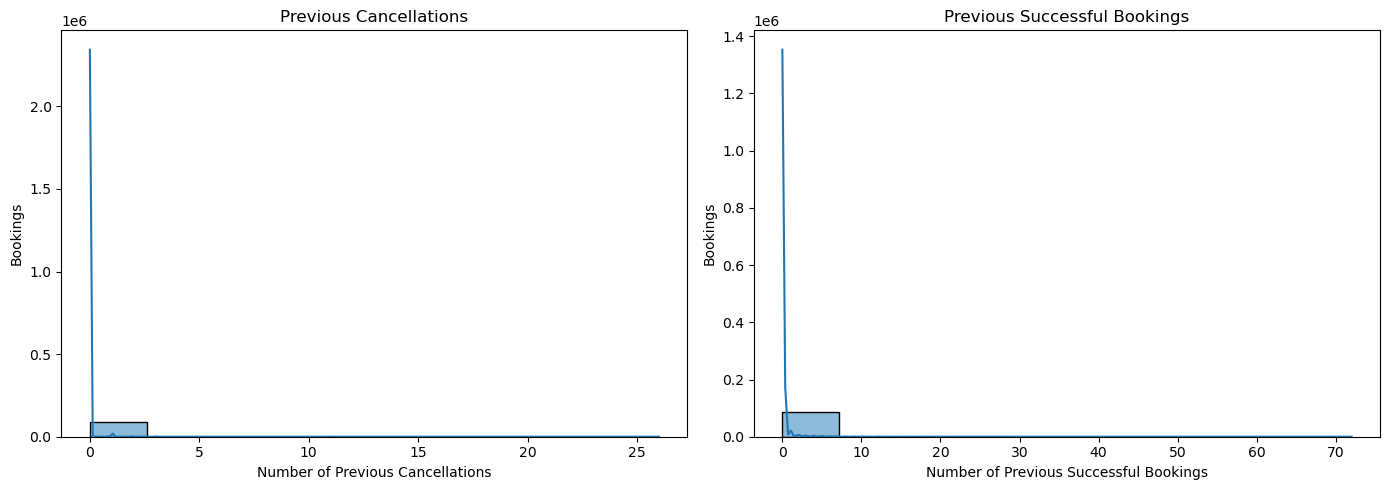

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=hotel_df,
    x="previous_cancellations",
    bins=10,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Previous Cancellations")
axes[0].set_xlabel("Number of Previous Cancellations")
axes[0].set_ylabel("Bookings")

sns.histplot(
    data=hotel_df,
    x="previous_bookings_not_canceled",
    bins=10,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Previous Successful Bookings")
axes[1].set_xlabel("Number of Previous Successful Bookings")
axes[1].set_ylabel("Bookings")

plt.tight_layout()
plt.show()

In [36]:
hotel_df[
    [
        "previous_cancellations",
        "previous_bookings_not_canceled"
    ]
].describe()

,previous_cancellations,previous_bookings_not_canceled
count,87370.000000,87370.000000
mean,0.030422,0.184045
std,0.369200,1.732148
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,26.000000,72.000000


### Observation

Most customers have no previous cancellations and no previous successful bookings, while only a small number of customers have a booking history.

### Insight

The dataset mainly consists of customers with little or no previous booking activity, indicating that many reservations are made by first-time or infrequent guests.

# Summary

In this notebook, I explored the individual features of the hotel booking dataset using univariate analysis. I analyzed both categorical and numerical variables to understand their distributions, customer preferences, booking behavior, and seasonal patterns. These observations provide a solid foundation for exploring relationships between variables in the next notebook.